In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
csv_path = "Names_hints/dpt2020.csv"
df = (
    pd.read_csv(csv_path, sep=";")
      .query("preusuel != '_PRENOMS_RARES'")
      .astype({"dpt": str})
)

df = df[df["annais"] != "XXXX"]

df.head()

,sexe,preusuel,annais,dpt,nombre
10885,1,AADIL,1983,84,3
10886,1,AADIL,1992,92,3
10888,1,AAHIL,2016,95,3
10892,1,AARON,1962,75,3
10893,1,AARON,1976,75,3


In [4]:
df["sexe"].value_counts()

sexe
2    1966210
1    1702064
Name: count, dtype: int64

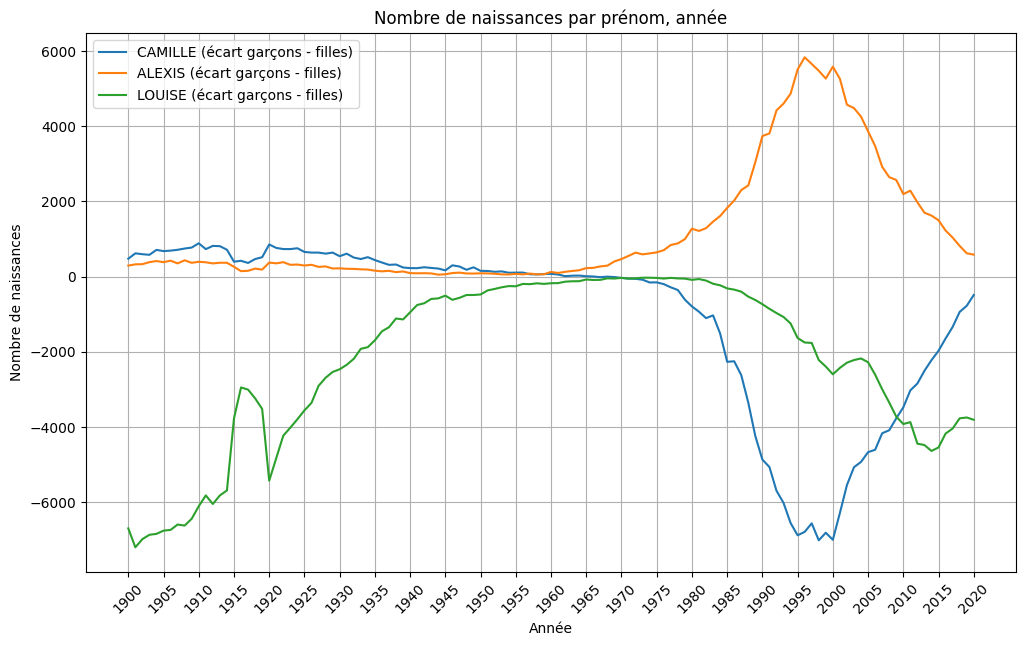

In [5]:
prenoms = ["CAMILLE", "ALEXIS", "LOUISE"]
colors = plt.cm.tab10.colors

""" plt.figure(figsize=(12, 7))

for idx, prenom in enumerate(prenoms):
    data_prenom = df[df["preusuel"] == prenom]
    data_grouped = data_prenom.groupby(["annais", "sexe"])["nombre"].sum().unstack(fill_value=0)
    for sexe in [1, 2]:
        if sexe not in data_grouped.columns:
            data_grouped[sexe] = 0
    data_grouped = data_grouped[[1, 2]]
    color = colors[idx % len(colors)]
    plt.plot(data_grouped.index, data_grouped[1], label=f"{prenom} (garçons)", color=color, linestyle='-')
    plt.plot(data_grouped.index, data_grouped[2], label=f"{prenom} (filles)", color=color, linestyle='--')
    equal_years = data_grouped.index[data_grouped[1] == data_grouped[2]]
    for i, year in enumerate(equal_years):
        plt.axvline(x=year, color=color, linestyle=':', alpha=0.7)
        if i == 0:
            plt.text(year, (plt.ylim()[0] + plt.ylim()[1]) / 2, f"égalité {prenom}", color=color, rotation=90, va='center', ha='right', fontsize=9)

plt.xlabel("Année")
plt.ylabel("Nombre de naissances")
plt.title("Nombre de naissances par prénom, année et sexe")
plt.legend()
plt.grid()
xticks = df["annais"].sort_values().unique()[::5]
plt.xticks(ticks=xticks, rotation=45)
plt.show() """

plt.figure(figsize=(12, 7))

for idx, prenom in enumerate(prenoms):
    data_prenom = df[df["preusuel"] == prenom]
    data_grouped = data_prenom.groupby(["annais", "sexe"])["nombre"].sum().unstack(fill_value=0)
    for sexe in [1, 2]:
        if sexe not in data_grouped.columns:
            data_grouped[sexe] = 0
    data_grouped = data_grouped[[1, 2]]
    data_diff = data_grouped[1] - data_grouped[2]
    color = colors[idx % len(colors)]
    plt.plot(data_diff.index, data_diff, label=f"{prenom} (écart garçons - filles)", color=color)

plt.xlabel("Année")
plt.ylabel("Nombre de naissances")
plt.title("Nombre de naissances par prénom, année")
plt.legend()
plt.grid()
xticks = df["annais"].sort_values().unique()[::5]
plt.xticks(ticks=xticks, rotation=45)
plt.show()


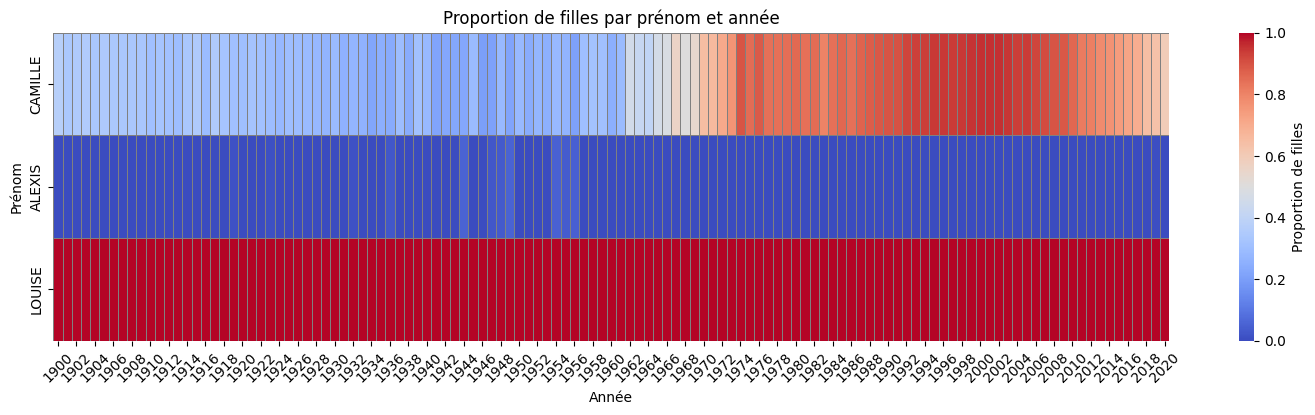

In [17]:
import seaborn as sns

prenoms_selectionnes = prenoms
df_heatmap = df[df["preusuel"].isin(prenoms_selectionnes)]

pivot = df_heatmap.pivot_table(
    index="preusuel",
    columns=["annais", "sexe"],
    values="nombre",
    aggfunc="sum",
    fill_value=0
)

years = sorted(df_heatmap["annais"].unique())
heatmap_data = []
for prenom in prenoms_selectionnes:
    row = []
    for year in years:
        nb_garcons = pivot.get((year, 1), pd.Series()).get(prenom, 0)
        nb_filles = pivot.get((year, 2), pd.Series()).get(prenom, 0)
        total = nb_garcons + nb_filles
        prop_filles = nb_filles / total if total > 0 else None
        row.append(prop_filles)
    heatmap_data.append(row)

heatmap_df = pd.DataFrame(heatmap_data, index=prenoms_selectionnes, columns=years)

plt.figure(figsize=(18, 4))
sns.heatmap(
    heatmap_df,
    cmap="coolwarm",
    cbar_kws={'label': 'Proportion de filles'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0, vmax=1
)
plt.title("Proportion de filles par prénom et année")
plt.xlabel("Année")
plt.ylabel("Prénom")
plt.xticks(rotation=45)
plt.show()